In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

train1 = pd.read_csv("MS2026012_train_var1.csv")
test1  = pd.read_csv("MS2026012_test_var1.csv")
train2 = pd.read_csv("MS2026012_train_var2.csv")
test2  = pd.read_csv("MS2026012_test_var2.csv")
train1.head()

,x1,x2,x3,x4,x5,x6,y
0,-1.000000,0.371010,-0.582002,-0.938291,1.000000,1.000000,8.634635
1,-0.408873,-1.000000,0.122301,-1.000000,-1.000000,-0.560793,6.869572
2,0.323120,-0.632110,0.119346,0.003576,0.987814,-0.057277,-0.593114
3,0.167993,0.544212,1.000000,1.000000,0.038691,0.442955,-3.757439
4,-1.000000,-1.000000,-0.513076,-0.221937,0.993203,0.316196,-0.609641


In [12]:
def degree_search(train, features, degrees, title=""):
    X, y = train[features].values, train["y"].values
    kf = KFold(5, shuffle=True, random_state=0)
    tr_err, cv_err = [], []
    for d in degrees:
        model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
        model.fit(X, y)
        tr_err.append(mean_squared_error(y, model.predict(X)))
        cv_err.append(-cross_val_score(model, X, y, cv=kf,
                      scoring="neg_mean_squared_error").mean())
    plt.plot(degrees, tr_err, "o-", label="Training error")
    plt.plot(degrees, cv_err, "s-", label="Cross-validation error")
    plt.yscale("log"); plt.xlabel("Degree"); plt.ylabel("MSE")
    plt.title(title); plt.legend(); plt.show()
    for d, t, c in zip(degrees, tr_err, cv_err):
        print(f"degree {d}: train MSE {t:.3f} | CV MSE {c:.3f}")

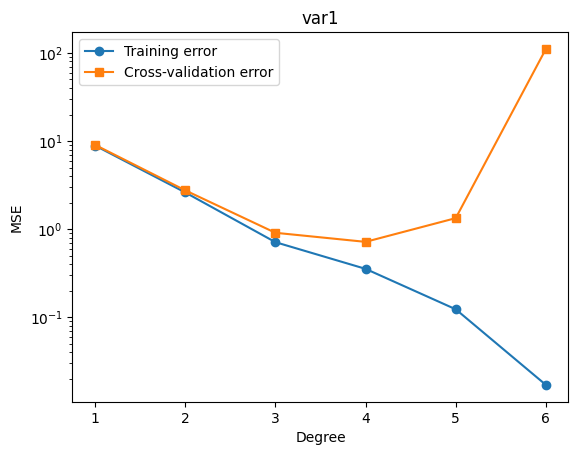

degree 1: train MSE 8.906 | CV MSE 9.070
degree 2: train MSE 2.617 | CV MSE 2.764
degree 3: train MSE 0.714 | CV MSE 0.912
degree 4: train MSE 0.355 | CV MSE 0.719
degree 5: train MSE 0.124 | CV MSE 1.337
degree 6: train MSE 0.017 | CV MSE 111.118


In [13]:
f1 = ["x1","x2","x3","x4","x5","x6"]
degree_search(train1, f1, range(1, 7), "var1")

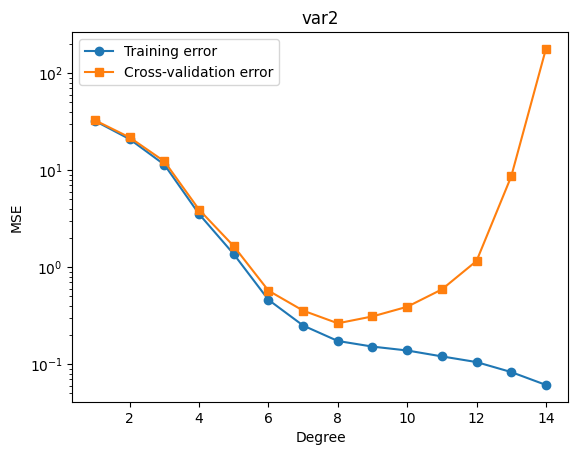

degree 1: train MSE 32.266 | CV MSE 32.757
degree 2: train MSE 20.929 | CV MSE 21.803
degree 3: train MSE 11.427 | CV MSE 12.344
degree 4: train MSE 3.536 | CV MSE 3.926
degree 5: train MSE 1.365 | CV MSE 1.649
degree 6: train MSE 0.461 | CV MSE 0.574
degree 7: train MSE 0.250 | CV MSE 0.357
degree 8: train MSE 0.173 | CV MSE 0.264
degree 9: train MSE 0.152 | CV MSE 0.311
degree 10: train MSE 0.138 | CV MSE 0.391
degree 11: train MSE 0.120 | CV MSE 0.590
degree 12: train MSE 0.105 | CV MSE 1.160
degree 13: train MSE 0.083 | CV MSE 8.643
degree 14: train MSE 0.061 | CV MSE 178.434


In [14]:
f2 = ["x1","x2","x3"]
degree_search(train2, f2, range(1, 15), "var2")

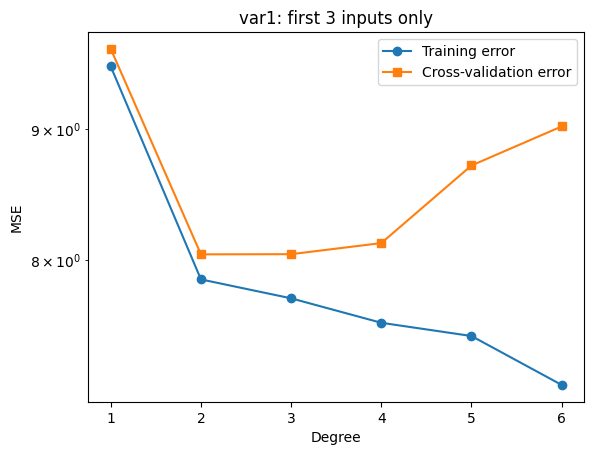

degree 1: train MSE 9.521 | CV MSE 9.673
degree 2: train MSE 7.860 | CV MSE 8.039
degree 3: train MSE 7.727 | CV MSE 8.040
degree 4: train MSE 7.558 | CV MSE 8.121
degree 5: train MSE 7.469 | CV MSE 8.709
degree 6: train MSE 7.147 | CV MSE 9.021


In [15]:
   degree_search(train1, ["x1","x2","x3"], range(1, 7), "var1: first 3 inputs only")



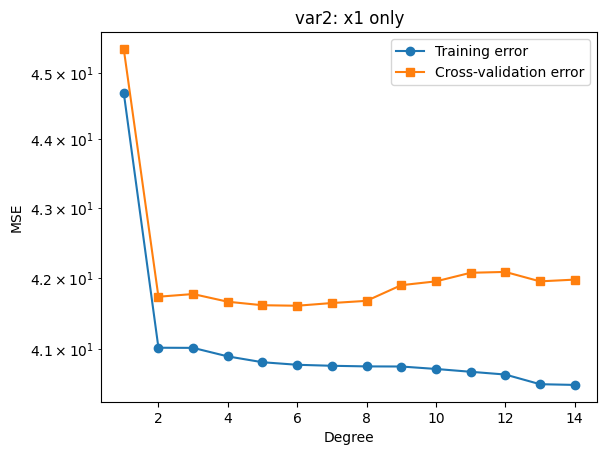

degree 1: train MSE 44.696 | CV MSE 45.359
degree 2: train MSE 41.020 | CV MSE 41.730
degree 3: train MSE 41.018 | CV MSE 41.768
degree 4: train MSE 40.901 | CV MSE 41.660
degree 5: train MSE 40.821 | CV MSE 41.611
degree 6: train MSE 40.786 | CV MSE 41.604
degree 7: train MSE 40.772 | CV MSE 41.642
degree 8: train MSE 40.763 | CV MSE 41.673
degree 9: train MSE 40.762 | CV MSE 41.893
degree 10: train MSE 40.728 | CV MSE 41.947
degree 11: train MSE 40.690 | CV MSE 42.068
degree 12: train MSE 40.652 | CV MSE 42.080
degree 13: train MSE 40.520 | CV MSE 41.947
degree 14: train MSE 40.510 | CV MSE 41.971


In [16]:
degree_search(train2, ["x1"], range(1, 15), "var2: x1 only")

In [17]:
best_degree = 4
model = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), LinearRegression())
model.fit(train1[f1].values, train1["y"].values)
pred1 = model.predict(test1[f1].values)
pd.DataFrame({"y": pred1}).to_csv("MS2026012_pred_var1.csv", index=False)

In [18]:
best_degree = 8
model = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), LinearRegression())
model.fit(train2[f2].values, train2["y"].values)
pred2 = model.predict(test2[f2].values)
pd.DataFrame({"y": pred2}).to_csv("MS2026012_pred_var2.csv", index=False)

In [19]:
print(pd.read_csv("MS2026012_pred_var1.csv").shape, pd.read_csv("MS2026012_pred_var2.csv").shape)


(1000, 1) (1000, 1)
